# Score a pipeline against the truth

Notebook 1 built a recording **forward** from its physics, and Notebook 2 inverted it,
demixing the overlapping cells to read their traces back out. This notebook asks the
question that makes a simulator worth having: **how well did a recovery match the
truth?** Because minisim
generated the recording, we hold the exact answer key - the true footprints,
calcium traces, spike counts, and motion - so we can grade a recovery instead of
guessing.

Grading sounds simple ("did it find the cells?") and is full of traps. A footprint
can overlap the right pixels yet smear its weight; a motion-corrected estimate can
sit a few pixels off the true frame through no fault of its own; the deconvolved `S`
a pipeline emits is **not** a spike train and must not be scored like one. This
notebook builds each recovery metric and, with it, the pitfall it is shaped to
avoid.

Two halves:

1. **Concepts and pitfalls** - each metric on controlled perturbations of the truth,
   so you *see* what it rewards and what it forgives.
2. **An end-to-end walkthrough** - mock an imperfect pipeline output, score it in one
   call, and read every line of the report.

> Unlike Notebook 1, this notebook is **static**: each demo sweeps a perturbation and
> plots the whole curve, so it reads correctly even without a live kernel. Every demo
> cell starts with a `# try:` knob - edit it and re-run to explore.

## Setup

We need the simulator (to make a recording with known truth) and the recovery
metrics. `minisim.testing.make_recording` is the one-call CI fixture from the
test-suite guide; the a-la-carte metrics (`hungarian_match`, `trace_pearson`,
`activity_similarity`, `shift_rmse`) and the one-call `score` come straight off the
top-level package. We also pull in `mediapy` to play the recording inline.

**A quick vocabulary**, since the rest leans on it (all standard CNMF/minian terms):
a **footprint** is a cell's spatial image - the pixels it lights up. A pipeline emits
three arrays per cell: **`A`** (footprints), **`C`** (the calcium trace over time), and
**`S`** (the deconvolved *activity*, a non-negative rate, *not* a spike train - more in
1.5). A cell is **detectable** when its transient is bright enough to clear the sensor
noise (an SNR test; see Notebook 1). **Ground truth** is the exact answer key minisim
kept. We grade with **recall** (fraction of true cells found) and **precision**
(fraction of found cells that are real).

Instead of `make_recording`'s default well-separated grid, we hand it a
`NeuronPopulation` and let minisim's **native volumetric sampler** place the cells: a
cell density over a depth range, the way the simulator builds any realistic scene. Two
consequences fall straight out of the physics, and the whole notebook is about coping
with them:

- **Overlap.** Nearby somata sit close enough that optical blur and tissue scatter
  spread their footprints into each other - the crowding the matching and trace scores
  below must cope with, which a tidy grid never produces.
- **A detectability gap.** The slab is thick (50-120 µm), so auto-focus can only sit on
  one plane; cells far from it defocus and dim, and at this modest exposure the faintest
  fall *under* the noise floor. The cell below prints the count and **draws it**: a max
  projection with the detectable cells circled and the undetectable ones crossed out -
  and the crossed cells visibly sit on faint blobs. They are real cells the microscope
  could not deliver, not pipeline failures.

That gap is the whole reason Part 2 reports an **honest recall denominator**: a pipeline
should be graded against the cells it *could* have found (`detectable_subset()`), not
punished for the ones the optics buried. We carry the detectable subset (`det`) through
the rest of the notebook and grade recoveries of it against the answer key minisim kept
(true footprints, traces, spike counts).

34 cells planted, 27 detectable (79%); focus auto-resolved to 90 um; movie (200, 128, 128)


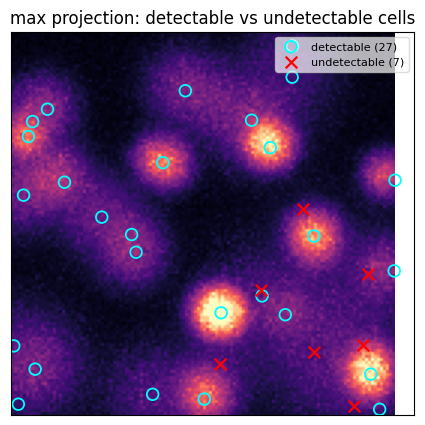

the recording to be scored (contrast-stretched for display) This browser does not support the video tag.


In [1]:
import mediapy
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import shift as ndshift

from minisim import (
    hungarian_match, trace_pearson, activity_similarity, shift_rmse,
    global_shift_from_trajectories, NeuronPopulation, Sensor,
)
from minisim.testing import make_recording, score, Estimate

%matplotlib inline
plt.rcParams["image.cmap"] = "magma"
plt.rcParams["figure.dpi"] = 100

# A fast, deterministic recording with ground truth, placed with minisim's native
# volumetric sampler: cells scattered through a 50-120 um slab (Poisson-disk spaced,
# 10 um minimum) over a 128 um FOV for 10 s, at a deliberately modest exposure. Two
# things this buys us, both of which the scores below have to live with:
#  - OVERLAP: nearby somata sit close enough that optical blur and tissue scatter spread
#    their footprints into each other (the crowding a tidy grid never produces).
#  - A DETECTABILITY GAP: the slab is thick, so auto-focus can only sit on one plane;
#    cells far from it defocus and dim, and the modest exposure lets the faintest fall
#    *under* the sensor noise floor. So not every planted cell is detectable - the gap
#    the honest recall denominator (Part 2) exists for.
pop = NeuronPopulation(density_per_mm3=30000, depth_range_um=(50.0, 120.0),
                       min_distance_um=10.0)         # try: change density / depth_range
rec = make_recording(population=pop, n_px=128, duration_s=10.0, seed=0,
                     sensor=Sensor(photons_per_unit=22.0))   # try: brighter -> smaller gap
gt = rec.ground_truth
det = gt.detectable_subset()
print(f"{gt.n_units} cells planted, {det.n_units} detectable "
      f"({det.n_units / gt.n_units:.0%}); focus auto-resolved to {gt.focal_depth_um:.0f} um; "
      f"movie {tuple(rec.observed.shape)}")


def shift_footprints(A, dy, dx):
    # Translate a footprint stack on its (height, width) axes, zero-filling the edge
    # (what a constant frame offset does to recovered footprints).
    return ndshift(np.asarray(A, float), (0, dy, dx), order=1, mode="constant", cval=0.0)


def footprint_similarity(est2d, true2d, *, metric="iou", energy_frac=0.9):
    # Single-footprint similarity under one metric, via the pairwise matcher.
    m = hungarian_match(est2d[None], true2d[None], metric=metric, energy_frac=energy_frac)
    return float(m.similarity_matrix[0, 0])


def energy_mask(a, energy_frac=0.9):
    # The binary mask IoU actually scores on (minisim's `_energy_masks`, for one
    # footprint): the *smallest* set of brightest pixels whose summed intensity
    # reaches `energy_frac` of the footprint's total. energy_frac=1.0 is the whole
    # positive support. This is what 1.2 draws as the "IoU boundary" contour.
    a = np.clip(np.asarray(a, float), 0.0, None)
    flat = a.ravel(); total = flat.sum()
    if total <= 0:
        return np.zeros(a.shape, bool)
    if energy_frac >= 1.0:
        return a > 0
    order = np.argsort(flat)[::-1]                    # brightest first
    csum = np.cumsum(flat[order])
    k = int(np.searchsorted(csum, energy_frac * total, side="left")) + 1
    mask = np.zeros(flat.size, bool); mask[order[:min(k, flat.size)]] = True
    return mask.reshape(a.shape)


def busiest_cell(S):
    # Index of the most active detectable cell - the clearest one for trace/activity demos.
    return int(np.argmax(np.asarray(S).sum(axis=1)))


def centers_in_px(ground_truth):
    # Soma (y, x) centers as pixel indices. Centers are in the optical-center frame
    # (0,0 = optical axis), so add half the FOV to land them in image coordinates.
    H, W = rec.observed.shape[1:]
    yx = np.asarray(ground_truth.centers_um)[:, 1:] / rec.spec.acquisition.pixel_size_um
    return yx + np.array([H / 2.0, W / 2.0])


# SEE the gap before scoring anything. The max-projection is the brightest each pixel
# ever got, so every cell that fired shows up. We circle the detectable cells and cross
# out the undetectable ones: the crossed cells sit on visibly faint blobs - real cells
# the optics put too far from the focal plane to clear the noise floor. This is what the
# recall denominator in Part 2 is protecting against - grading a pipeline for "missing"
# a cell the microscope never actually delivered.
_mp = np.asarray(rec.observed, np.float32).max(axis=0)
_yx = centers_in_px(gt); _d = np.asarray(gt.detectable)
fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.imshow(np.clip(_mp / np.percentile(_mp, 99.5), 0, 1))
ax.scatter(_yx[_d, 1], _yx[_d, 0], s=70, facecolors="none", edgecolors="cyan",
           linewidths=1.3, label=f"detectable ({_d.sum()})")
ax.scatter(_yx[~_d, 1], _yx[~_d, 0], s=70, marker="x", color="red",
           linewidths=1.6, label=f"undetectable ({(~_d).sum()})")
ax.legend(loc="upper right", fontsize=8, framealpha=0.7)
ax.set(title="max projection: detectable vs undetectable cells", xticks=[], yticks=[])
plt.show()

# Now play the movie a pipeline actually sees - the cells flicker as their calcium rises
# and falls, and where two sit close their light merges (the footprint overlap the scores
# below must cope with). The undetectable cells from the panel above are the dim flickers
# that never quite stand out. Contrast-stretched for display only; the answer key
# (true A, C, S) is what we score a recovery against.
_mov = np.asarray(rec.observed, np.float32)
_vmax = float(np.percentile(_mov, 99.7)) or 1.0
mediapy.show_video(np.clip(_mov / _vmax, 0.0, 1.0), fps=rec.spec.acquisition.fps,
                   title="the recording to be scored (contrast-stretched for display)")

# Part 1 - the metrics, and the traps they avoid

Each section perturbs the truth in one controlled way and watches a metric respond.
The recipe is always the same: take the ground truth, break it deliberately, score
it, and read what the number does.

## 1.1 Matching cells - which estimate is which truth?

Every recovery score starts by deciding *which* recovered footprint corresponds to
*which* true cell. `hungarian_match` builds the pairwise spatial-overlap matrix
between the estimated and true footprints and solves the optimal one-to-one
assignment. From the match come the familiar detection scores:

- **recall** - fraction of true cells recovered (paired with overlap above the match
  threshold),
- **precision** - fraction of estimates that are real (same threshold),
- **mean overlap** - average overlap over the matched pairs.

> **The scores below are all 1.00 on purpose.** This first demo feeds the *truth itself*
> back in as a flawless "estimate", so every cell matches itself perfectly - there is
> nothing to get wrong yet. Don't read the numbers; read the **shape of the matrix**.
> That is the lesson here. (Every later section breaks the truth in one specific way and
> the numbers start to move.)

Matching is two stages, and only the second uses a threshold. The **assignment** is
threshold-free: it pairs estimates to truth to maximize total overlap, dropping only
pairs with *zero* overlap. The **match threshold** is then applied to decide which of
those pairs count as recovered - a pair is a true positive only if its overlap clears
it. That threshold is **0.5 by default** (the conventional cell-detection bar; like the
detection floor it is a provisional convention, not a calibrated truth - pass a
different value to `recall()` / `precision()` / `score(match_threshold=...)`).

Match against `A_observed` - the optically degraded footprint, which is the most a
pipeline could recover - not the sharp, optics-free `A_planted`. Because our cells are
scattered, some footprints overlap, so the overlap matrix is **not** purely diagonal -
a cell shares some overlap with its close neighbours (the bright off-diagonal entries;
one is circled). The diagonal still dominates (each footprint overlaps *itself* most),
so the Hungarian assignment still recovers the right pairing - which is exactly why
matching is posed as an *assignment* problem (the Hungarian algorithm, the standard
optimal one-to-one matcher) and not a per-row `argmax`: once estimates are imperfect,
those off-diagonal entries are what a naive match would trip over.

recall=1.00  precision=1.00  mean overlap=1.00  (27 pairs)  <- all 1.00 by construction; look at the matrix shape


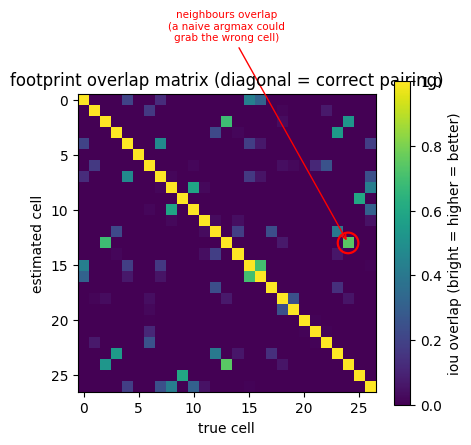

In [2]:
def show_perfect_match():
    # try: change the matching metric, or the match threshold. (Here the estimate IS
    # the truth, so every diagonal pair has overlap 1 and the threshold has no effect
    # until it exceeds 1; it starts to bite once the estimate is imperfect - see 1.3
    # and Part 2.)
    match_metric = "iou"          # "iou" | "cosine" | "weighted_jaccard"
    match_threshold = 0.5         # min overlap for a pair to count as recovered
    A = np.asarray(det.A_observed)
    m = hungarian_match(A, A, metric=match_metric)               # estimate == truth
    print(f"recall={m.recall(match_threshold):.2f}  precision={m.precision(match_threshold):.2f}  "
          f"mean overlap={m.mean_similarity:.2f}  ({len(m.pairing)} pairs)  "
          f"<- all 1.00 by construction; look at the matrix shape")
    # Find the brightest off-diagonal entry (a cell overlapping a *neighbour*) to point at.
    S = m.similarity_matrix.copy(); np.fill_diagonal(S, 0.0)
    i, j = np.unravel_index(int(np.argmax(S)), S.shape)
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    im = ax.imshow(m.similarity_matrix, vmin=0, vmax=1, cmap="viridis")
    ax.scatter([j], [i], s=220, facecolors="none", edgecolors="red", linewidths=1.6)
    ax.annotate("neighbours overlap\n(a naive argmax could\ngrab the wrong cell)",
                (j, i), xytext=(0.5, 1.18), textcoords="axes fraction", fontsize=7.5,
                ha="center", color="red",
                arrowprops=dict(arrowstyle="->", color="red", lw=1.0))
    ax.set(xlabel="true cell", ylabel="estimated cell",
           title="footprint overlap matrix (diagonal = correct pairing)")
    fig.colorbar(im, ax=ax, label=f"{match_metric} overlap (bright = higher = better)")
    plt.show()


show_perfect_match()

## 1.2 Pitfall: which matching metric, and what it is blind to

Matching needs a *footprint similarity*, and the choice is not innocent. A recovered
footprint can be wrong in two independent ways: it can sit at the wrong **position**
(an offset), or it can light the right pixels but spread its **weight** wrong (a
smeared intensity profile). The three metrics `hungarian_match` offers weigh those two
errors very differently (each returns a number in 0..1, 1 = identical):

- **IoU** (*intersection-over-union*, the default) is a *binary* test: turn each
  footprint into a **mask** (a set of lit pixels) and score `shared pixels / combined
  pixels` of the two masks - it ignores the values inside, only which pixels are on.
  minisim takes that mask as the top-`energy_frac` of each footprint's energy (default
  **`energy_frac=0.9`**, i.e. the smallest pixel set holding 90% of the energy; we score
  at the default throughout, since the only alternative that is exactly weight-blind,
  `energy_frac=1.0` = the entire support including the near-zero blur tail, is not how
  anyone actually matches).
- **cosine** (*cosine similarity*) - flatten each footprint to a vector and take the
  cosine of the angle between them; 1 = same direction, and it is scale-free (doubling a
  footprint's brightness does not change it).
- **weighted Jaccard** (the *Ruzicka* similarity) - `sum(min) / sum(max)` of the two
  sum-normalized footprints; the graded analogue of IoU (it compares the weight profile,
  not just the lit pixels).

We take one true footprint and build an "estimate" from it broken **both** ways at
once: flattened by a power `gamma`, and translated by an offset. *Flattening by gamma*
means raising every pixel to a power - at `gamma=1` it's the true footprint, and as
`gamma -> 0` the bright centre spreads out toward a uniform disk over the **same**
lit pixels (the shape goes flat, the support doesn't move). The *offset* just slides
the whole footprint by a few pixels.

**Figure 1** shows what that means and, in cyan, the IoU mask each version is scored on
(`energy_frac=0.9` made concrete). Watch the cyan boundary against the dashed white
reference (the truth's mask): on the flattened copy the mask has **grown** - spreading
the weights pushes energy out of the core, so more pixels are needed to hold 90% of it -
while the offset copy carries the same-size mask, just slid off the reference. (The exact
size depends on the cell and the cutoff; turn the `# try:` knobs and watch the
*direction*, not the pixel count.)

**Figure 2** scores `similarity(estimate, truth)` over the full (gamma x offset) grid,
one heatmap per metric (bright = better match):

- **All three fall to the right** (with offset): none tolerates a position error on its
  own. Section 1.3 is about absorbing a *global* offset so it stops looking like a miss.
- **Down the `gamma` axis they differ.** *cosine* is the most forgiving of a flattened
  profile, *weighted_jaccard* the strictest - both compare the weight profile directly.
  *IoU* also drops, but for an indirect reason: flattening grows the 90%-energy mask
  (the cyan outline in Figure 1), and IoU is reacting to that **mask-area** change, not
  to the weights themselves (and the exact slope depends on the arbitrary 0.9 cutoff).
  That is the pitfall - if you care whether the *weight profile* is right, score with a
  weighted metric; IoU only ever sees the mask.

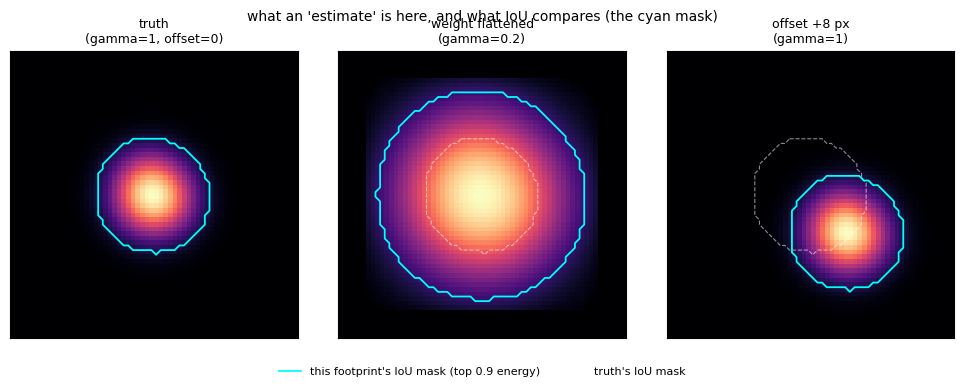

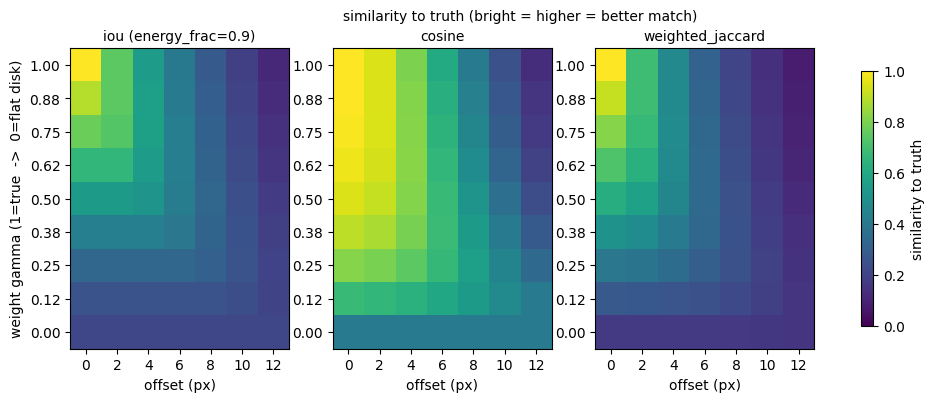

In [3]:
from matplotlib.lines import Line2D


def centered_detectable_cell():
    # The most active detectable cell whose footprint sits clear of the FOV edge, so
    # the zoom below shows a whole, unclipped footprint (not a corner-cropped sliver).
    A = np.asarray(det.A_observed); H, W = A.shape[1:]
    for u in np.argsort(np.asarray(det.S).sum(axis=1))[::-1]:
        ys, xs = np.where(A[u] > 0)
        if ys.min() > 2 and xs.min() > 2 and ys.max() < H - 3 and xs.max() < W - 3:
            return int(u)
    return busiest_cell(det.S)


def show_pixel_weights():
    # try: change the IoU energy_frac, pick a different cell, or change the ranges.
    iou_energy_frac = 0.9        # default mask = top 90% of energy; 1.0 = full support
    u = centered_detectable_cell()
    true = np.asarray(det.A_observed[u])
    support = true > 0

    # Build an "estimate" from the truth, broken two independent ways, and score it
    # against the truth with each metric over the whole (weight x offset) grid:
    #   - weight profile: raise to a power gamma (1 = true, -> 0 = flat disk over the
    #     same pixels), so the lit pixels are unchanged but the brightness profile is.
    #   - offset: translate the whole footprint by (k, k) px (no shift correction here).
    gammas = np.linspace(1.0, 0.0, 9)
    offsets = np.arange(0, 13, 2)
    metrics = ["iou", "cosine", "weighted_jaccard"]
    mats = {m: np.zeros((gammas.size, offsets.size)) for m in metrics}
    for i, g in enumerate(gammas):
        base = np.where(support, true ** g, 0.0)
        for j, k in enumerate(offsets):
            est = shift_footprints(base[None], k, k)[0]
            for m in metrics:
                # energy_frac only affects iou (it defines the binary mask); the
                # weighted metrics ignore it and compare the profile directly.
                mats[m][i, j] = footprint_similarity(est, true, metric=m, energy_frac=iou_energy_frac)

    ys, xs = np.where(support); pad = 6
    y0, y1 = max(ys.min() - pad, 0), min(ys.max() + pad + 1, true.shape[0])
    x0, x1 = max(xs.min() - pad, 0), min(xs.max() + pad + 1, true.shape[1])

    # FIGURE 1 - what "estimate" means, and what IoU actually sees. Each thumbnail draws
    # its OWN IoU mask in cyan (the top-`iou_energy_frac` energy pixels, the only thing
    # IoU compares); the faint dashed white outline on the broken copies is the truth's
    # mask, for reference. Watch the cyan boundary: flattening the weights spreads the
    # energy so the mask GROWS past the reference; an offset slides the same-size mask
    # off it. Those are the two pitfalls, made visible.
    true_mask = energy_mask(true, iou_energy_frac)
    thumbs = [("truth\n(gamma=1, offset=0)", true, False),
              ("weight flattened\n(gamma=0.2)", np.where(support, true ** 0.2, 0.0), True),
              ("offset +8 px\n(gamma=1)", shift_footprints(true[None], 8, 8)[0], True)]
    fig1, axes = plt.subplots(1, 3, figsize=(10, 3.7))
    for ax, (ttl, img, show_ref) in zip(axes, thumbs):
        ax.imshow(img[y0:y1, x0:x1])
        if show_ref:
            ax.contour(true_mask[y0:y1, x0:x1], levels=[0.5], colors="w",
                       linewidths=0.8, alpha=0.55, linestyles="dashed")
        ax.contour(energy_mask(img, iou_energy_frac)[y0:y1, x0:x1], levels=[0.5],
                   colors="cyan", linewidths=1.3)
        ax.set_title(ttl, fontsize=9); ax.set_xticks([]); ax.set_yticks([])
    fig1.legend(handles=[Line2D([], [], color="cyan", lw=1.3,
                                label=f"this footprint's IoU mask (top {iou_energy_frac:g} energy)"),
                         Line2D([], [], color="w", lw=0.8, ls="dashed", label="truth's IoU mask")],
                loc="lower center", ncol=2, fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.04))
    fig1.suptitle("what an 'estimate' is here, and what IoU compares (the cyan mask)", fontsize=10)
    fig1.tight_layout(rect=(0, 0.05, 1, 1))
    plt.show()

    # FIGURE 2 - similarity(estimate, truth) over weight x offset, one panel per metric.
    fig2, axes = plt.subplots(1, 3, figsize=(12, 3.9))
    for ax, m in zip(axes, metrics):
        im = ax.imshow(mats[m], vmin=0, vmax=1, cmap="viridis", aspect="auto")
        ax.set_xticks(range(offsets.size)); ax.set_xticklabels(offsets)
        ax.set_yticks(range(gammas.size)); ax.set_yticklabels([f"{g:.2f}" for g in gammas])
        ax.set_title(f"iou (energy_frac={iou_energy_frac:g})" if m == "iou" else m, fontsize=10)
        ax.set_xlabel("offset (px)")
    axes[0].set_ylabel("weight gamma (1=true  ->  0=flat disk)")
    fig2.suptitle("similarity to truth (bright = higher = better match)", fontsize=10)
    fig2.colorbar(im, ax=list(axes), label="similarity to truth", shrink=0.85, location="right")
    plt.show()


show_pixel_weights()

## 1.3 Pitfall: a global shift is not a miss

After motion correction the recovered footprints live in the pipeline's *template*
frame, which can sit a few pixels off minisim's reference - and the offset differs
between pipelines (rigid vs non-rigid registration, different templates). Scored
naively, a uniform translation of every footprint looks like a total failure even
when the recovery is otherwise perfect.

`hungarian_match` absorbs it. Pass `shift="auto"` to find the single `(dy, dx)` that
best slides every footprint onto the truth (under the hood it phase-correlates the
footprint supports - a standard image-registration trick - robust to a few missed or
spurious cells, and it only adopts the shift if it actually improves the match), or
pass a known `(dy, dx)`. Below, the left panel slides a perfect estimate sideways and
scores recall both ways: raw recall collapses once the offset exceeds the footprint
overlap, while `shift="auto"` holds it flat (the slow droop at large offsets is honest
- footprints shifted off the FOV edge are clipped, and that mass is genuinely lost).

The two right panels are the **1.1 overlap matrix at one offset (5 px)**, scored
without and with the shift. Without it the diagonal has faded - every estimate still
gets paired with its true cell, but their overlap has dropped below the match threshold
(IoU 0.5), so none counts as recovered (recall 0). `shift="auto"` recovers the
`(-5, -5)` translation and the bright diagonal snaps back above 0.5: the recovery was
perfect all along, only the frame was off.

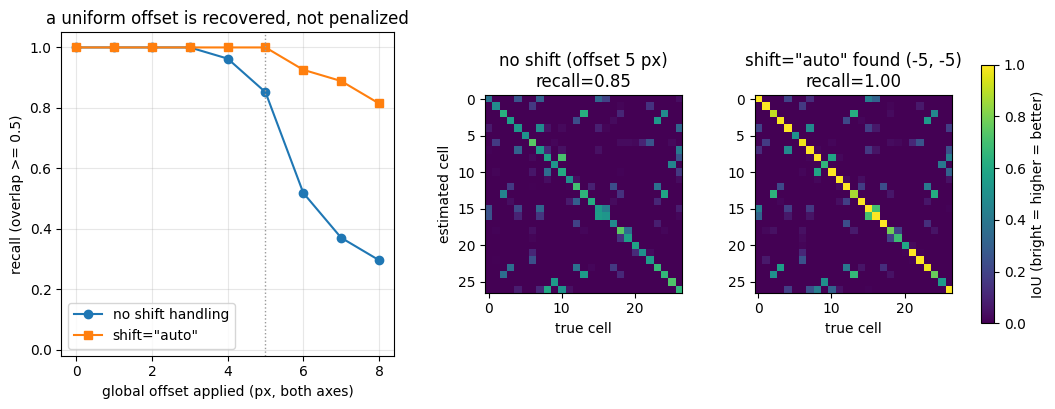

In [4]:
def show_global_shift():
    # try: change the match threshold, the representative offset k0, the offset range,
    # or set the matching metric below.
    match_threshold = 0.5
    k0 = 5                                            # offset shown in the two matrices
    A = np.asarray(det.A_observed)
    offsets = range(0, 9)
    raw, auto = [], []
    for k in offsets:
        A_off = shift_footprints(A, k, k)            # every footprint moved by (k, k) px
        raw.append(hungarian_match(A_off, A).recall(match_threshold))
        auto.append(hungarian_match(A_off, A, shift="auto").recall(match_threshold))

    # The same overlap matrix as 1.1, at one representative offset, scored without and
    # with shift handling - to see what the global offset does to the match itself.
    A_off = shift_footprints(A, k0, k0)
    m_raw = hungarian_match(A_off, A)
    m_auto = hungarian_match(A_off, A, shift="auto")

    fig = plt.figure(figsize=(13, 4.2))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.35, 1, 1], wspace=0.33)
    axc = fig.add_subplot(gs[0, 0])
    axc.plot(list(offsets), raw, marker="o", label="no shift handling")
    axc.plot(list(offsets), auto, marker="s", label='shift="auto"')
    axc.axvline(k0, color="0.6", ls=":", lw=1)
    axc.set(xlabel="global offset applied (px, both axes)", ylabel=f"recall (overlap >= {match_threshold})",
            title="a uniform offset is recovered, not penalized", ylim=(-0.02, 1.05))
    axc.legend(); axc.grid(alpha=0.3)
    for col, (m, ttl) in enumerate([
        (m_raw, f"no shift (offset {k0} px)\nrecall={m_raw.recall(match_threshold):.2f}"),
        (m_auto, f'shift="auto" found {m_auto.shift}\nrecall={m_auto.recall(match_threshold):.2f}'),
    ]):
        ax = fig.add_subplot(gs[0, 1 + col])
        im = ax.imshow(m.similarity_matrix, vmin=0, vmax=1, cmap="viridis")
        ax.set(xlabel="true cell", title=ttl)
        if col == 0:
            ax.set_ylabel("estimated cell")
    fig.colorbar(im, ax=fig.axes[1:], label="IoU (bright = higher = better)", shrink=0.8)
    plt.show()


show_global_shift()

When the pipeline reports its **motion trajectory**, the offset need not be searched
for at all: the constant difference between the estimated correction and the true
applied motion *is* the footprint offset. `global_shift_from_trajectories` reads it
straight off, and `score` (Part 2) uses it automatically when both trajectories are
present.

## 1.4 Recovering the calcium trace

For each matched pair, `trace_pearson` correlates the recovered calcium trace against
the true `C`. It returns the **Pearson correlation r** - the standard correlation
coefficient, from -1 to 1, measuring how well two traces rise and fall *together*
(1 = perfectly in step, 0 = unrelated). Crucially r is invariant to scale and offset,
so it scores the *shape* of the recovered dynamics, not its absolute level (a pipeline's
trace is in arbitrary fluorescence units). Here we corrupt a true trace with increasing
noise and watch the correlation fall.

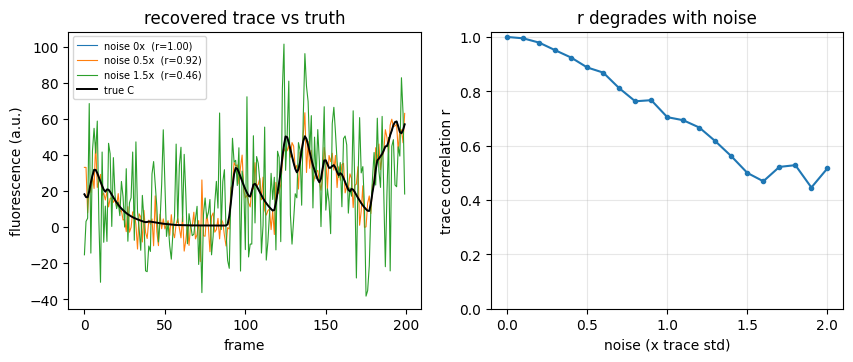

In [5]:
def show_trace_recovery():
    # try: change the noise levels (x trace std), the sweep, or the cell.
    noise_levels = (0.0, 0.5, 1.5)        # example traces to overlay
    sweep = np.linspace(0, 2, 21)         # noise grid for the degradation curve
    cell = busiest_cell(det.S)
    true = np.asarray(det.C[cell]); rng = np.random.default_rng(1)
    sd = true.std()
    fig, (axt, axc) = plt.subplots(1, 2, figsize=(10, 3.6))
    t = np.arange(true.size)
    for frac in noise_levels:
        est = true + rng.normal(0, frac * sd, true.size)
        r = trace_pearson(est[None], true[None], ((0, 0),))[0]
        axt.plot(t, est, lw=0.8, label=f"noise {frac:g}x  (r={r:.2f})")
    axt.plot(t, true, color="k", lw=1.4, label="true C")
    axt.set(xlabel="frame", ylabel="fluorescence (a.u.)", title="recovered trace vs truth")
    axt.legend(fontsize=7)
    rs = [trace_pearson((true + rng.normal(0, f * sd, true.size))[None], true[None], ((0, 0),))[0]
          for f in sweep]
    axc.plot(sweep, rs, marker="o", ms=3); axc.set(xlabel="noise (x trace std)",
             ylabel="trace correlation r", title="r degrades with noise", ylim=(0, 1.02))
    axc.grid(alpha=0.3)
    plt.show()


show_trace_recovery()

## 1.5 Pitfall: the deconvolved `S` is not a spike train

The array a pipeline calls `S` (CNMF/minian "spikes") is **not** a list of action
potentials. It is a non-negative estimate of neural **activity rate**, scaled by an
unknown factor that maps activity to calcium-kernel amplitude. Two consequences for
scoring:

1. **Do not binarize it.** Thresholding `S` into "spike / no spike" throws away the
   graded amplitude, which is most of the information, and makes the score hostage to
   an arbitrary threshold.
2. **Allow an unknown scale.** The estimate and the truth differ by a gain factor, so
   the metric must be invariant to it (and can usefully *report* it).

`activity_similarity` does both. Per matched pair it returns three numbers:

- **correlation** - the Pearson r between estimate and truth (shape match, scale- and
  offset-invariant, just like 1.4),
- **scale** - the recovered non-negative gain that best maps the estimate onto the true
  activity (the unknown factor, made explicit),
- **variance explained** - the fraction of the true activity's variance the scaled
  estimate accounts for: `1 - SS_residual / SS_total`. 1 = perfect, 0 = no better than
  guessing the mean, and it can go *negative* if the fit is worse than the mean.

The true target is `gt.S` - the per-frame spike *counts* from the biology (those are real
spikes); what the pipeline emits to approximate it is the non-spike activity estimate.

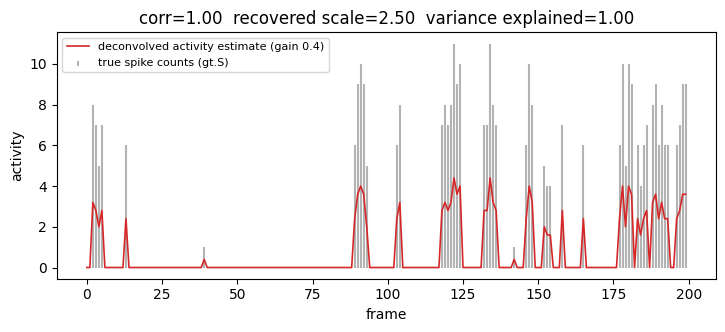

In [6]:
def show_activity_is_not_spikes():
    # try: change the unknown gain, or the cell.
    gain = 0.4                             # the (unknown) factor mapping activity -> S
    cell = busiest_cell(det.S)
    # The true per-frame spike counts (real, integer) vs a plausible deconvolved
    # estimate: a non-negative, graded activity rate at an arbitrary gain.
    true = np.asarray(det.S[cell]); t = np.arange(true.size)
    est = gain * true                      # same shape, unknown gain
    act = activity_similarity(est[None], true[None], ((0, 0),))
    fig, ax = plt.subplots(figsize=(8.5, 3.2))
    ax.stem(t, true, basefmt=" ", linefmt="0.7", markerfmt=" ", label="true spike counts (gt.S)")
    ax.plot(t, est, color="C3", lw=1.2, label=f"deconvolved activity estimate (gain {gain:g})")
    ax.set(xlabel="frame", ylabel="activity", title=(
        f"corr={act.correlation[0]:.2f}  recovered scale={act.scale[0]:.2f}  "
        f"variance explained={act.variance_explained[0]:.2f}"))
    ax.legend(fontsize=8)
    plt.show()


show_activity_is_not_spikes()

### Scale invariance: the metric recovers the unknown gain

Take a true activity and define the estimate as `true / k` for a range of gains `k`.
A scale-aware metric should report **correlation ~ 1** and **variance explained ~ 1**
for every `k` (the shape is perfect), while the recovered **scale** tracks `k` - it
has measured the unknown gain.

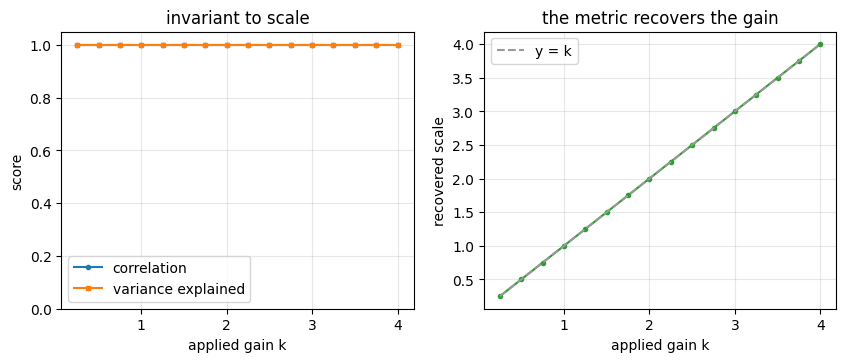

In [7]:
def show_scale_invariance():
    # try: change the gain range, or the cell.
    gains = np.linspace(0.25, 4.0, 16)
    cell = busiest_cell(det.S)
    true = np.asarray(det.S[cell], float)
    corr, pve, scale = [], [], []
    for k in gains:
        est = true / k                      # estimate is the truth at gain 1/k
        a = activity_similarity(est[None], true[None], ((0, 0),))
        corr.append(a.correlation[0]); pve.append(a.variance_explained[0]); scale.append(a.scale[0])
    fig, (axl, axr) = plt.subplots(1, 2, figsize=(10, 3.6))
    axl.plot(gains, corr, marker="o", ms=3, label="correlation")
    axl.plot(gains, pve, marker="s", ms=3, label="variance explained")
    axl.set(xlabel="applied gain k", ylabel="score", title="invariant to scale", ylim=(0, 1.05))
    axl.legend(); axl.grid(alpha=0.3)
    axr.plot(gains, scale, marker="o", ms=3, color="C2")
    axr.plot(gains, gains, ls="--", color="0.6", label="y = k")
    axr.set(xlabel="applied gain k", ylabel="recovered scale", title="the metric recovers the gain")
    axr.legend(); axr.grid(alpha=0.3)
    plt.show()


show_scale_invariance()

### Why not binarize: amplitude errors a threshold cannot see

Two estimates fire on the **same frames**: one matches the true amplitudes, the other
flattens every event to height 1. A threshold-based spike precision/recall calls both
*perfect* (identical nonzero frames). `activity_similarity` does not: the flattened
estimate explains less of the true variance, because it gets the amplitudes wrong.

In [8]:
def naive_spike_precision_recall(est, true, thr=0.0):
    # The OLD, binarized approach, for contrast only: a frame is a "spike" if it
    # exceeds thr. It is blind to amplitude.
    e = np.asarray(est) > thr; t = np.asarray(true) > thr
    tp = int((e & t).sum())
    prec = tp / int(e.sum()) if e.sum() else 0.0
    rec = tp / int(t.sum()) if t.sum() else 0.0
    return prec, rec


def show_no_binarize():
    # try: change the cell.
    cell = busiest_cell(det.S)
    true = np.asarray(det.S[cell], float)
    graded = true.copy()                    # right frames, right amplitudes
    flat = (true > 0).astype(float)         # right frames, wrong (flattened) amplitudes
    for name, est in [("graded (correct amplitudes)", graded), ("flattened (amplitudes lost)", flat)]:
        a = activity_similarity(est[None], true[None], ((0, 0),))
        p, r = naive_spike_precision_recall(est, true)
        print(f"{name:32s}  binarized P/R = {p:.2f}/{r:.2f}   "
              f"variance explained = {a.variance_explained[0]:.2f}")
    print("\nThe binarized score cannot tell the two apart; variance explained can.")


show_no_binarize()

graded (correct amplitudes)       binarized P/R = 1.00/1.00   variance explained = 1.00
flattened (amplitudes lost)       binarized P/R = 1.00/1.00   variance explained = 0.89

The binarized score cannot tell the two apart; variance explained can.


## 1.6 Motion: score the tracking, not the origin

If the spec has brain motion, `gt.shifts` is the true per-frame `(dy, dx)`.
`shift_rmse` compares a pipeline's estimated trajectory against it and returns the
**RMSE** - the *root-mean-square error*: square the per-frame `(dy, dx)` difference,
average over all frames and both axes, take the square root. It is a single number in
**pixels** answering "how far off is the estimated shift, typically?" (0 = perfect; it
penalizes big misses more than small ones). Two flags matter:

- `correction=True` negates the estimate - a motion-*correction* trajectory is the
  negation of the applied motion (it is what you would apply to undo it).
- `align=True` removes a constant per-axis offset before the RMSE. Each pipeline
  registers to its own template, so the absolute zero frame is arbitrary; aligning
  scores how well the *motion* was tracked rather than which frame was called zero.

Below, a trajectory that tracks the motion perfectly but sits at a constant offset
scores a large raw RMSE and ~0 once aligned.

raw RMSE = 2.55 px    aligned RMSE = 0.00 px
constant offset read off the trajectories (-> footprint shift): (-3, 2)


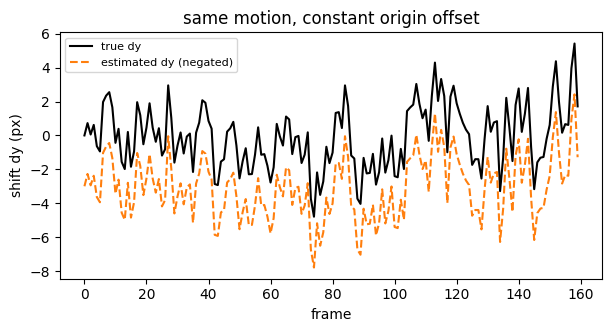

In [9]:
def show_motion():
    # try: change the constant template offset, the per-frame tracking noise, or the
    # recording duration (a longer clip = a longer, more interesting trajectory).
    template_offset = (3.0, -2.0)            # constant origin difference (px) vs minisim's frame
    traj_noise_px = 0.0                      # per-frame noise on the estimated trajectory
    # A roomy 256 um FOV (2 um/px) so the default brain-motion amplitude is a realistic
    # few percent of the frame (a 96 um teaching FOV makes the same motion look huge).
    recm = make_recording(n_cells=6, n_px=128, pixel_size_um=2.0, duration_s=8.0,
                          motion=True, seed=1)
    true = np.asarray(recm.ground_truth.shifts)
    rng = np.random.default_rng(0)
    correction = -true + np.array(template_offset)   # perfect correction, shifted template
    if traj_noise_px:
        correction = correction + rng.normal(0, traj_noise_px, correction.shape)
    raw = shift_rmse(correction, true, correction=True)
    aligned = shift_rmse(correction, true, correction=True, align=True)
    offset = global_shift_from_trajectories(correction, true)
    print(f"raw RMSE = {raw:.2f} px    aligned RMSE = {aligned:.2f} px")
    print(f"constant offset read off the trajectories (-> footprint shift): {offset}")
    fig, ax = plt.subplots(figsize=(7, 3.2))
    t = np.arange(true.shape[0])
    ax.plot(t, true[:, 0], color="k", label="true dy")
    ax.plot(t, (-correction)[:, 0], color="C1", ls="--", label="estimated dy (negated)")
    ax.set(xlabel="frame", ylabel="shift dy (px)", title="same motion, constant origin offset")
    ax.legend(fontsize=8)
    plt.show()


show_motion()

# Part 2 - score a recovery end to end

Part 1 used one metric at a time on a clean perturbation. In practice you run a
pipeline, get back footprints / traces / activity / a motion trajectory, and want a
single honest scorecard. That is `minisim.testing.score`, which bundles every metric
above and applies the conventions you would otherwise have to remember (match against
`A_observed`, score recall over the detectable cells, absorb a global footprint
offset, score activity up to scale, align the motion origin).

## 2.1 Mock an imperfect pipeline output

To keep the notebook dependency-free we do not run a real pipeline here (running an
actual pipeline like minian and scoring it lives in that pipeline's own test suite, via
`minisim.testing`). Instead we *fake* a realistic recovery by breaking the truth the way a pipeline
would: miss a few dim cells, invent a couple of spurious ones, shift the footprints, add
trace noise, and emit the activity at an unknown gain. `Estimate` is the container
`score` takes; its fields accept either the terse CNMF symbols (`A`, `C`, `S`) or
spelled-out aliases (`footprints`, `traces`, `activity`).

In [10]:
def mock_recovery(gt, *, n_miss=1, miss_frac=None, n_false=1, template_shift=(3, 2),
                  trace_noise=0.3, activity_gain=2.0, seed=2):
    # Build a plausible-but-imperfect Estimate from the detectable truth. If the
    # recording has motion, the recovered footprints sit at a constant `template_shift`
    # off minisim's reference (a different registration template) and the estimated
    # correction over-shoots the true motion by that same constant - so the offset is
    # real but recoverable from the trajectory.
    rng = np.random.default_rng(seed)
    det = gt.detectable_subset()
    # How many detectable cells the mock pipeline misses. A fixed count by default; pass
    # `miss_frac` to miss a constant *fraction* instead - what a depth sweep (2.5) needs,
    # so "recall over detectable" reflects a steady recovery quality rather than a fixed
    # count eating a shrinking detectable population.
    miss = round(miss_frac * det.n_units) if miss_frac is not None else n_miss
    miss = max(0, min(miss, det.n_units))
    A = np.asarray(det.A_observed); C = np.asarray(det.C); S = np.asarray(det.S)
    has_motion = det.shifts is not None
    keep = slice(miss, None)                          # "miss" the first `miss` cells
    A_keep, C_keep, S_keep = A[keep], C[keep], S[keep]
    fp_shift = template_shift if has_motion else (0, 0)
    A_est = shift_footprints(A_keep, *fp_shift)
    C_est = C_keep + rng.normal(0, trace_noise * C_keep.std(axis=1, keepdims=True), C_keep.shape)
    S_est = S_keep / activity_gain                   # activity at an unknown gain
    shifts_est = (-np.asarray(det.shifts) + np.array(template_shift)) if has_motion else None
    if n_false:                                      # invent spurious footprints in empty corners
        h, w = A.shape[1:]; false = np.zeros((n_false, h, w))
        for i in range(n_false):
            cy, cx = rng.integers(12, h - 12), rng.integers(12, w - 12)
            yy, xx = np.ogrid[:h, :w]
            false[i] = np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * 4.0 ** 2))
        A_est = np.concatenate([A_est, false])
        C_est = np.concatenate([C_est, rng.normal(0, 1, (n_false, C.shape[1]))])
        S_est = np.concatenate([S_est, np.abs(rng.normal(0, 0.1, (n_false, S.shape[1])))])
    return Estimate(A=A_est, C=C_est, activity=S_est, shifts=shifts_est)


# A recording WITH brain motion AND a detectability gap, so the end-to-end score
# exercises everything at once: the motion trajectory (and the global footprint offset
# it implies), and an honest recall denominator (some planted cells are too deep/dim to
# detect). A roomy 256 um FOV (2 um/px) keeps the brain motion a realistic few percent
# of the frame; volumetric placement over a 40-110 um slab at a modest exposure gives
# the gap; motion=True appends the brain-motion step. ~48 cells makes the medians robust.
pop2 = NeuronPopulation(density_per_mm3=10000, depth_range_um=(40.0, 110.0), min_distance_um=10.0)
rec2 = make_recording(population=pop2, n_px=128, pixel_size_um=2.0, duration_s=6.0,
                      motion=True, seed=0, sensor=Sensor(photons_per_unit=24.0))
gt2 = rec2.ground_truth
# try: change how the mock pipeline fails - miss more cells, invent more false
# positives, add more trace noise, or change the unknown activity gain.
est = mock_recovery(gt2, n_miss=2, n_false=2, trace_noise=0.3, activity_gain=2.0)
print(f"estimate: {np.asarray(est.A).shape[0]} footprints "
      f"(truth: {gt2.detectable_subset().n_units} detectable of {gt2.n_units} planted, with motion)")

estimate: 33 footprints (truth: 33 detectable of 48 planted, with motion)


## 2.2 Score it in one call

`score(estimate, ground_truth)` returns a `Report`. Its `summary()` is a compact,
test-friendly digest; every field is also a plain attribute.

In [11]:
# try: change the matching metric or the match threshold (recall denominator is the
# subject of 2.3, so it is varied there).
match_metric = "iou"            # "iou" | "cosine" | "weighted_jaccard"
match_threshold = 0.5
report = score(est, gt2, match_metric=match_metric, match_threshold=match_threshold)
print(report.summary())

cells: recall=0.91 precision=0.91 f1=0.91 (matched 30/33, mean iou 0.91)
population: 33 detectable of 48 planted (recall denominator = 33)
traces: median r=0.96
activity: median r=1.00 variance explained=1.00 (scale=2)
footprint shift applied: (-3, -2) px (dy, dx)
motion: RMSE=0.00 px (offset-aligned)


Reading the report field by field:

- **recall / precision / f1** - detection quality (f1 = the harmonic mean of precision
  and recall, a single number that is high only when *both* are). The missed cells cost
  recall; the spurious footprints cost precision.
- **mean_overlap** - average footprint overlap over the matched pairs (under
  `match_metric`, IoU by default). It is **high (~0.9)** here because our mock's
  footprints are literal (shifted) copies of the true ones, so once `score` absorbs the
  global shift the matched masks nearly coincide; it falls short of 1 only where crowded
  neighbours bleed into each other. A *real* pipeline re-estimates blurred footprints, so
  its mean_overlap lands lower - this near-1 is mostly an artifact of the mock, not a
  property of the metric.
- **footprint_shift** - the global `(dy, dx)` `score` absorbed before matching, read
  off the motion trajectory, so the template offset we baked in did not masquerade as
  missed cells.
- **trace_corr** - median trace correlation over matched pairs.
- **activity_corr / activity_variance_explained / activity_scale** - the deconvolved
  activity scored up to scale; `activity_scale` is the recovered gain (~2, the gain we
  applied).
- **shift_rmse** - motion error in pixels (origin-aligned); small here, since the mock
  correction tracks the true motion up to the constant template offset.

In [12]:
for f in ("recall", "precision", "f1", "mean_overlap", "footprint_shift",
          "trace_corr", "activity_corr", "activity_variance_explained",
          "activity_scale", "shift_rmse"):
    print(f"{f:30s} {getattr(report, f)}")

recall                         0.9090909090909091
precision                      0.9090909090909091
f1                             0.9090909090909091
mean_overlap                   0.9133791923522949
footprint_shift                (-3, -2)
trace_corr                     0.9593350063696933
activity_corr                  1.0
activity_variance_explained    1.0
activity_scale                 2.0000000000000018
shift_rmse                     1.411628674897425e-16


## 2.3 The honest denominator

A recall number is only meaningful if you know what it is over. This recording has a
**detectability gap** (some planted cells are too deep or dim to clear the noise floor,
exactly like the Setup panel), so the choice of denominator actually moves the number.
By default `score` counts recall against the **detectable** cells, and the report
always carries the three counts so a high recall over a shrunken denominator can never
be mistaken for "recovered everything":

- `n_requested` - cells planted,
- `n_detectable` - cells above the detection floor,
- `n_true` - the denominator recall actually used.

Pass `restrict_to_detectable=False` to grade against every planted cell instead (the
undetectable ones then count as misses). The two numbers below differ precisely because
of the gap: over the detectable cells the mock looks good, but over *everything planted*
it is also penalized for cells the optics buried - which is the honest "yield" number,
not a pipeline failure.

In [13]:
print(f"planted={report.n_requested}  detectable={report.n_detectable}  "
      f"recall denominator={report.n_true}")
full = score(est, gt2, restrict_to_detectable=False)
print(f"recall over detectable={report.recall:.2f}   over all planted={full.recall:.2f} "
      f"(denominator {full.n_true})")

planted=48  detectable=33  recall denominator=33


recall over detectable=0.91   over all planted=0.62 (denominator 48)


## 2.4 Adapt it to your pipeline

For a real run, replace the mock with your pipeline's output and pass it straight to
`score`. The footprints are the only required field; leave traces / activity / shifts
out and those scores come back as `nan` / `None`.

```python
from minisim import simulate
from minisim.testing import Estimate, score

rec = simulate(spec)
A_est, C_est, S_est, shifts_est = run_my_pipeline(rec.observed)

report = score(
    Estimate(A=A_est, C=C_est, activity=S_est, shifts=shifts_est),
    rec.ground_truth,
    match_metric="cosine",     # weigh pixel weights, not just lit pixels (optional)
)
assert report.recall > 0.8, report.summary()
```

When both the estimated and true motion trajectories are present, `score` reads the
global footprint offset straight off them (Section 1.3); otherwise it estimates the
offset by overlap. The {doc}`benchmarking guide <../../../docs/howto/benchmark>` has
the same recipe outside a notebook, and the test-suite guide wires it into `pytest`.

## 2.5 Scaling up: a metric across a physical axis

A single scorecard answers "how did this run do?". The deeper questions are physical:
how does recall fall with **depth**, with **density**, with **NA**? Drive this same
`score` call from a parameter sweep (one recording per point on the axis) and collect
the reports into a table - recall vs depth is the canonical curve, and it is where a
*real* pipeline would calibrate the provisional detection threshold against measured
recovery (we use the mock here, so this shows the *shape*, not a calibrated number).

Two details make the curve honest rather than flat:

- **The focal plane is pinned** (`focal_depth_um=0.0`), not `"auto"`. Auto-focus
  refocuses on whatever depth you place the cells at, so every cell stays in focus and
  bright and recall never moves. Holding the plane at the surface lets the physics act:
  deeper cells defocus and scatter dims them, their SNR falls, and they drop below the
  detection floor (the `N det` annotations show that population shrinking).
- **The mock misses a constant 15%** (`miss_frac`), not a fixed count. That separates
  the two curves cleanly:
  - **recall over detectable (quality)** stays roughly flat - the pipeline recovers a
    steady fraction of whatever is above the floor, at any depth. (At the deepest points
    only a cell or two are detectable, so "miss 15%" rounds to missing none and it reads
    as 1.0 - honest quantization, not a recovery that got *better* with depth.)
  - **recall over all planted (yield)** falls - the fraction of the cells you put in the
    tissue that a pipeline can get back. The drop is entirely the shrinking detectable
    population, which is exactly the quantity a depth study measures.

This is Section 2.3's two denominators turned into a curve: quality is flat, yield
falls, and the gap between them *is* the detectability physics. That sweep is the
natural sequel to this notebook: the metrics here are the `y`-axis of every such study.

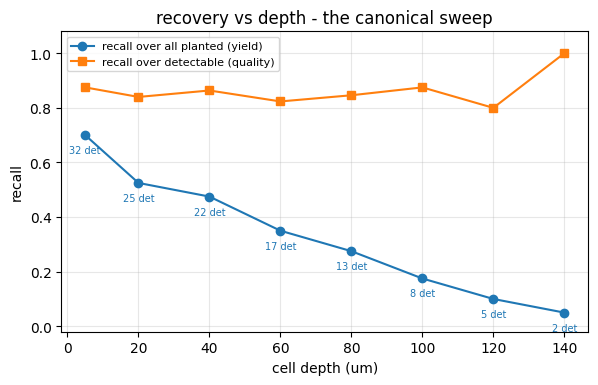

In [14]:
def show_recall_vs_depth():
    # try: change the depths, the fixed focal plane, the exposure, the miss fraction,
    # or n_cells. One fresh recording + mock recovery per depth.
    depths = [5, 20, 40, 60, 80, 100, 120, 140]
    focal_depth_um = 0.0         # FIXED focal plane (surface); see below for why
    photons_per_unit = 250.0     # dim enough that the depth falloff straddles the floor
    miss_frac = 0.15             # mock pipeline misses a constant 15% of detectable cells
    n_cells = 40                 # a roomy population so the curves are smooth
    # The focal plane is pinned (not "auto"): with auto-focus the simulator refocuses
    # on each depth, every cell stays in focus and bright, and the curve is flat. Held
    # still at the surface, deeper cells defocus and scatter dims them, so their SNR
    # falls and fewer clear the detection floor - the physics this curve is about.
    planted, detectable, n_det = [], [], []
    for d in depths:
        r = make_recording(n_cells=n_cells, n_px=128, duration_s=2.0, depth_um=float(d),
                           focal_depth_um=focal_depth_um, sensor=Sensor(photons_per_unit=photons_per_unit),
                           seed=0)
        g = r.ground_truth
        # Constant-quality mock (misses a fixed FRACTION, not a fixed count), so the
        # detectable-recall curve isn't an artifact of a shrinking denominator.
        est_d = mock_recovery(g, miss_frac=miss_frac)
        planted.append(score(est_d, g, restrict_to_detectable=False).recall)
        detectable.append(score(est_d, g, restrict_to_detectable=True).recall)
        n_det.append(int(np.asarray(g.detectable).sum()))
    fig, ax = plt.subplots(figsize=(6.8, 3.9))
    ax.plot(depths, planted, marker="o", label="recall over all planted (yield)")
    ax.plot(depths, detectable, marker="s", label="recall over detectable (quality)")
    for x, y, n in zip(depths, planted, n_det):       # annotate the shrinking denominator
        ax.annotate(f"{n} det", (x, y), textcoords="offset points", xytext=(0, -13),
                    ha="center", fontsize=7, color="C0")
    ax.set(xlabel="cell depth (um)", ylabel="recall",
           title="recovery vs depth - the canonical sweep", ylim=(-0.02, 1.08))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.show()


show_recall_vs_depth()

## Recap

- **Matching** pairs estimates to truth by spatial overlap; recall / precision / f1
  follow. Use **weighted** overlap (`cosine`, `weighted_jaccard`) when pixel weights
  matter, and **`shift`** to absorb a global offset after motion correction.
- **Traces** are scored by scale-invariant correlation.
- **Activity** (`S`) is a scaled rate, not spikes: score it without binarizing and up
  to an unknown gain, which `activity_similarity` reports.
- **Motion** is scored with `shift_rmse`, aligning away the arbitrary origin.
- **`score`** bundles all of this into one honest `Report`, with the recall
  denominator always in view.

These metrics are the answer key Notebook 1's forward simulation exists to provide,
and the `y`-axis of every benchmarking study built on minisim.